In [1]:
import sys, os, h5py, time, psutil

import numpy as np
import healpy as hp
import tensorflow as tf

from tqdm import tqdm, trange
from sklearn.neighbors import BallTree

from deepsphere.utils import split_sparse_dense_matmul

from msfm.grid_pipeline import GridPipeline

23-10-31 03:24:11   imports.py INF   Setting up healpy to run on 32 CPUs 
23-10-31 03:24:12   imports.py INF   Setting up healpy to run on 32 CPUs 


# constants

In [2]:
sigma_arcmin = 15
n_sigma_support = 3
sigma_rad = sigma_arcmin / 60 / 180 * np.pi

# example map

In [3]:
tfr_pattern = "/pscratch/sd/a/athomsen/DESY3/v5/linear_bias/tfrecords/grid/DESy3_grid_000.tfrecord"
conf = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v5/linear_bias.yaml"
params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

grid_pipe = GridPipeline(
    conf=conf,
    params=params,
    with_lensing=True,
    with_clustering=False,
    with_padding=True,
    apply_norm=False
)

dv_pix = grid_pipe.data_vec_pix
n_dv_pix = len(dv_pix)

n_side = 512
n_pix = hp.nside2npix(n_side)

n_channels = grid_pipe.n_z_metacal# + grid_pipe.n_z_maglim
n_noise = 3

batch_size = 5

dset = grid_pipe.get_dset(
        tfr_pattern=tfr_pattern,
        n_noise=n_noise,
        local_batch_size=batch_size,
        n_readers=1,
        n_prefetch=0,
)

for dv, cosmo, index in dset.take(1):
    pass

print(dv.shape)

23-10-31 03:24:13     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-10-31 03:24:13     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-10-31 03:24:14 grid_pipelin INF   Interleaving with n_readers = 1 
23-10-31 03:24:15 grid_pipelin INF   Batching into 5 elements locally 
23-10-31 03:24:15 grid_pipelin WAR   Tracing _augmentations 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attac

# tree

In [4]:
# lon, lat = hp.pix2ang(n_side, ipix=dv_pix, nest=True, lonlat=True)
# theta = np.vstack([np.radians(lat), np.radians(lon)]).T

# print(f"creating tree for {len(theta)} pixels and radius {n_sigma_support*sigma_arcmin} arcmin")
# tree = BallTree(theta, metric="haversine")

# # determine the maximum number of neighbors
# inds_r, dist_r = tree.query_radius(theta, r=sigma_rad * n_sigma_support, return_distance=True, sort_results=True)
# n_neighbours = [len(i) for i in inds_r]
# max_neighbours = np.max(n_neighbours)
# print(f"max_neighbours = {max_neighbours}")

# # find the per pixel nearest neighbors
# theta_split = np.array_split(theta, 100)
# list_dist_k, list_inds_k = [], []
# for theta_ in tqdm(theta_split):
#     dist_k, inds_k = tree.query(theta_, k=max_neighbours, return_distance=True, sort_results=True)
#     list_dist_k.append(dist_k)
#     list_inds_k.append(inds_k)
# dist_k = np.concatenate(list_dist_k, axis=0)
# inds_k = np.concatenate(list_inds_k, axis=0)

# np.save(f"dist_k_nside{nside}.npy", dist_k)
# np.save(f"inds_k_nside{nside}.npy", inds_k)
# print(f"stored dist_k = {dist_k.shape}, inds_k = {inds_k.shape}")

In [5]:
dist_k = np.load(f"dist_k_nside{n_side}.npy")
inds_k = np.load(f"inds_k_nside{n_side}.npy")
print(f"loaded dist_k = {dist_k.shape}, inds_k = {inds_k.shape}")

max_neighbours = inds_k.shape[1]

loaded dist_k = (464896, 140), inds_k = (464896, 140)


# (sparse) kernel

In [6]:
# normalize later
kernel_func = lambda r: np.exp(-0.5 / sigma_rad**2 * r**2)

kernel = kernel_func(dist_k).astype(np.float32)
inds_k = inds_k.astype(np.int64)

print(f"kernel size {kernel.nbytes/1e9:4.2f} GB dtype {kernel.dtype}")
print(f"index size {inds_k.nbytes/1e9:4.2f} GB dtype {inds_k.dtype},  max_ind = {np.max(inds_k)}")
# print(f"single map tensor {dv_pix * max_neighbours * 4/1e9:4.2f} GB")

kernel size 0.26 GB dtype float32
index size 0.52 GB dtype int64,  max_ind = 464895


In [7]:
%%time   
kernel_channels = []
for i in range(n_channels):
    # row, all of the pixels in the patch
    inds_r = tf.constant(np.arange(n_dv_pix), dtype=tf.int64)
    inds_r = tf.expand_dims(inds_r, axis=-1)
    # same as tf.repeat(inds_r, max_neighbours, axis=1) in this case
    inds_r = tf.tile(inds_r, (1, max_neighbours))
    
    # column, all of the pixels that we want to sum over
    inds_c = tf.constant(inds_k, dtype=tf.int64)
    
    # shape (n_non_zero, 2)
    ind_coo = tf.concat([tf.reshape(inds_r, (-1, 1)), tf.reshape(inds_c, (-1, 1))], axis=-1)
    
    # shape(n_non_zero,)
    val_kernel = tf.reshape(kernel, (-1,))

    sparse_kernel = tf.sparse.SparseTensor(indices=ind_coo, values=val_kernel, dense_shape=(n_dv_pix, n_dv_pix))
    sparse_kernel = tf.sparse.reorder(sparse_kernel)
    
    # normalize
    col_sum = tf.sparse.reduce_sum(sparse_kernel, axis=1, output_is_sparse=False)
    sparse_kernel = sparse_kernel / tf.expand_dims(col_sum, axis=0)

    kernel_channels.append(sparse_kernel)

    print(f"sparse_kernel.shape = {sparse_kernel.shape}, ind_coo.shape = {ind_coo.shape}, ind_coo.size = {np.array(ind_coo).nbytes/1e9:2.4f} GB, val_kernel.shape = {val_kernel.shape}, val_kernel.size = {np.array(val_kernel).nbytes/1e9:2.4f} GB")

print(f"len(kernel_channels) = {len(kernel_channels)}, kernel_channels[0].shape = {kernel_channels[0].shape}, dv.shape = {dv.shape}")

sparse_kernel.shape = (464896, 464896), ind_coo.shape = (65085440, 2), ind_coo.size = 1.0414 GB, val_kernel.shape = (65085440,), val_kernel.size = 0.2603 GB
sparse_kernel.shape = (464896, 464896), ind_coo.shape = (65085440, 2), ind_coo.size = 1.0414 GB, val_kernel.shape = (65085440,), val_kernel.size = 0.2603 GB
sparse_kernel.shape = (464896, 464896), ind_coo.shape = (65085440, 2), ind_coo.size = 1.0414 GB, val_kernel.shape = (65085440,), val_kernel.size = 0.2603 GB
sparse_kernel.shape = (464896, 464896), ind_coo.shape = (65085440, 2), ind_coo.size = 1.0414 GB, val_kernel.shape = (65085440,), val_kernel.size = 0.2603 GB
len(kernel_channels) = 4, kernel_channels[0].shape = (464896, 464896), dv.shape = (5, 464896, 4)
CPU times: user 19.2 s, sys: 3.26 s, total: 22.4 s
Wall time: 18.1 s


In [8]:
%%time
dv_smooth = []
for i in range(n_channels):
    dv_channels_last = tf.transpose(dv[...,i], (1,0))
    dv_channels_last = tf.sparse.sparse_dense_matmul(kernel_channels[i], dv_channels_last)
    dv_channels_first = tf.transpose(dv_channels_last, (1,0))
    
    dv_smooth.append(dv_channels_first)

dv_smooth = tf.stack(dv_smooth, axis=-1)
print(dv_smooth.shape)

(5, 464896, 4)
CPU times: user 57.2 ms, sys: 162 ms, total: 219 ms
Wall time: 255 ms


# plotting

In [9]:
i_batch = 0
i_tomo = 0

### healpy

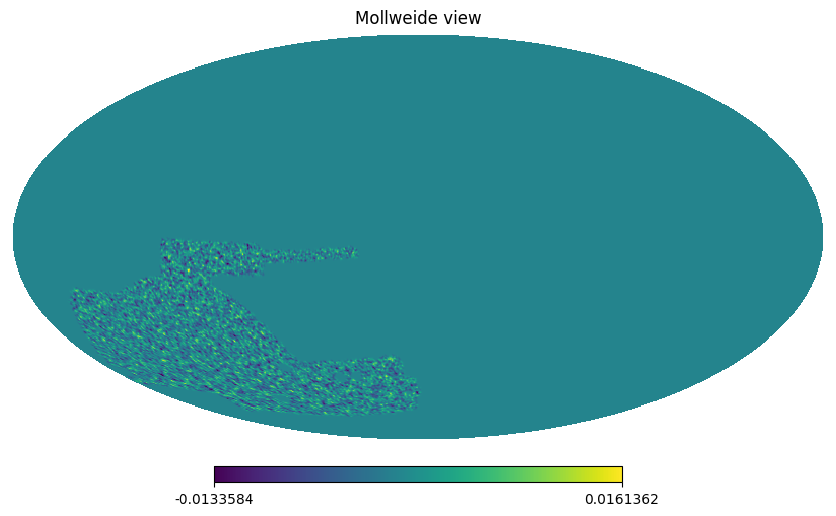

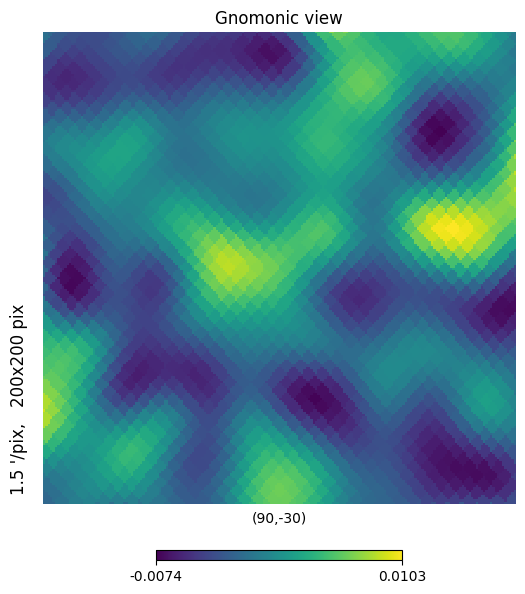

In [10]:
hp_map = np.zeros(n_pix)
hp_map[dv_pix] = dv[i_batch,:,i_tomo]
hp_map = hp.reorder(hp_map, n2r=True)

hp_smooth = hp.sphtfunc.smoothing(hp_map, sigma=sigma_rad)

hp.mollview(hp_smooth)
hp.gnomview(hp_smooth, rot=(90, -30, 0))

### tensorflow

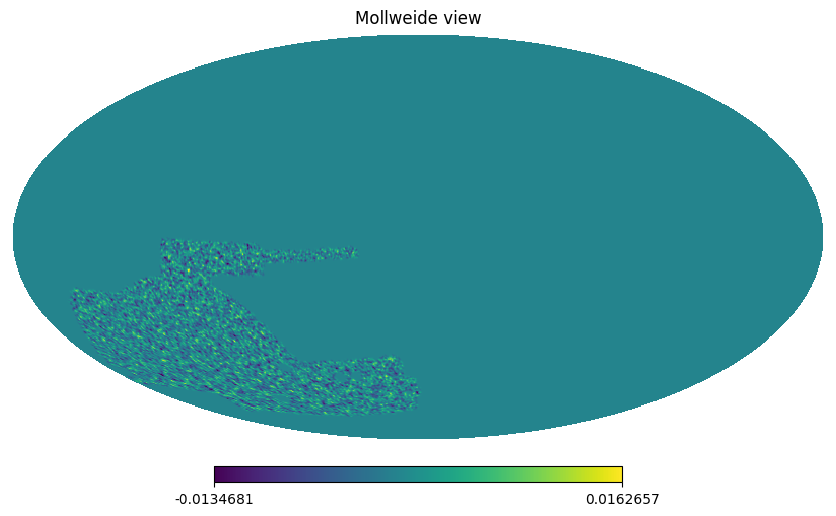

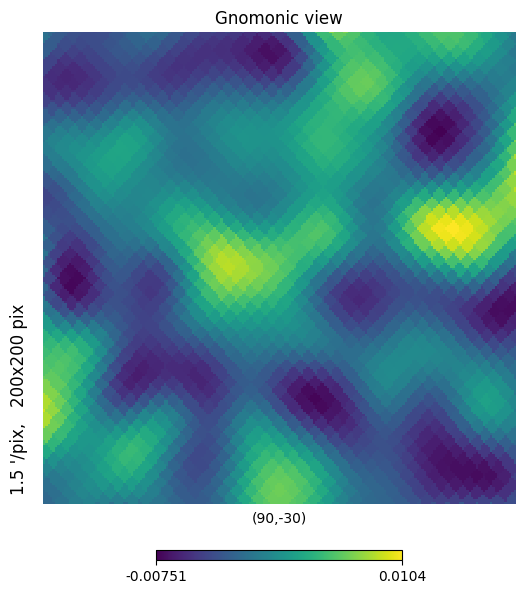

In [11]:
tf_smooth = np.zeros(n_pix)
tf_smooth[dv_pix] = dv_smooth[i_batch,:,i_tomo].numpy()

hp.mollview(tf_smooth, nest=True)
hp.gnomview(tf_smooth, rot=(90, -30, 0), nest=True)

vmin = tf_smooth.min()
vmax = tf_smooth.max()

### difference

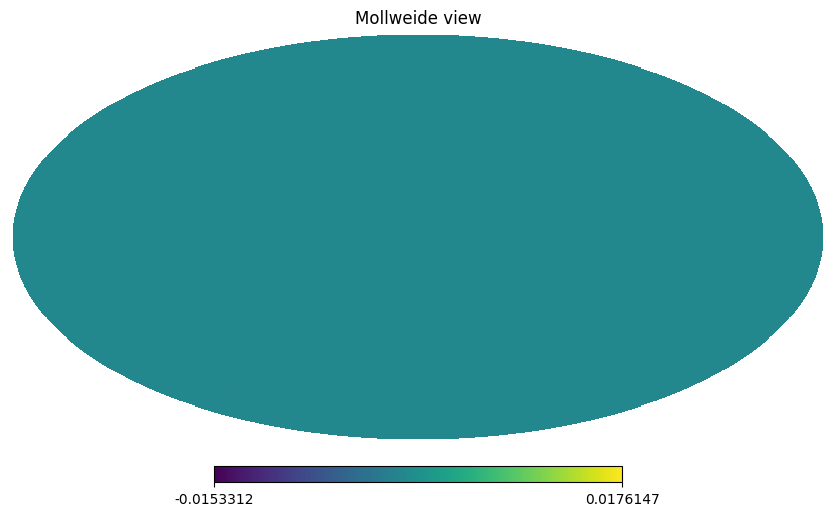

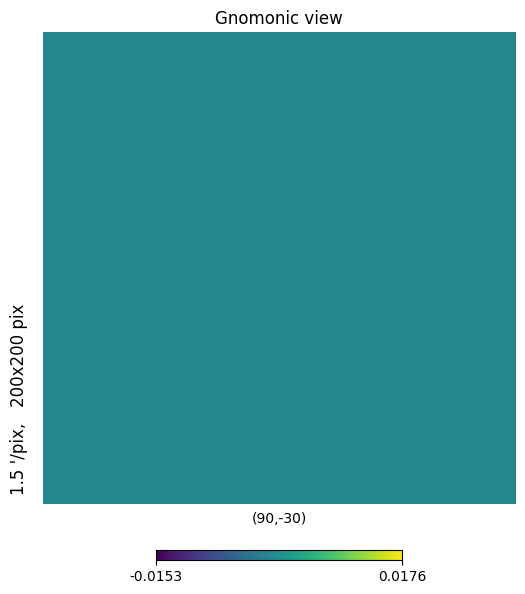

In [12]:
diff_smooth = hp.reorder(hp_smooth, r2n=True) - tf_smooth

hp.mollview(diff_smooth, nest=True, min=vmin, max=vmax)
hp.gnomview(diff_smooth, rot=(90, -30, 0), nest=True, min=vmin, max=vmax)